# Instrumental variable analysis for multi-model LLM gateways

**Keywords:** product experimentation, causal inference, instrumental variables,
2SLS, two-stage least squares, LLM routing, confounded experiments,
LATE, complier average causal effect, Python

This notebook accompanies the freeCodeCamp article:
*"Unconfounding the AI product experiment: instrumental variable analysis
for multi-model LLM gateways in Python"*

## Dataset

The shared synthetic LLM product dataset contains **50,000 users** with
telemetry simulating a SaaS product's multi-model gateway. The dataset is
generated with a known causal structure so we can verify that our estimators
recover the ground-truth effects.

For this IV demonstration, three variables are added on top of the base dataset:

| Variable | Type | Description |
|---|---|---|
| `rate_limit_fallback` | Instrument (Z) | Bernoulli(0.15), independent of query characteristics |
| `routed_to_premium_actual` | Endogenous treatment (D) | Routing after fallback overrides; confounded by unobserved query complexity |
| `task_completed_iv` | Outcome (Y) | Task completion rate; true premium effect = +0.06 |

Ground-truth causal effect of premium routing: **+6 percentage points**
The naive OLS is biased downward (~+3.3 pp) because unobserved query complexity
routes harder queries to premium, and harder queries complete less often.

## Clone and run

```bash
git clone https://github.com/RudrenduPaul/product-experimentation-causal-inference-genai-llm.git
cd product-experimentation-causal-inference-genai-llm
python data/generate_data.py --seed 42 --n-users 50000 --out data/synthetic_llm_logs.csv
python 11_instrumental_variables/iv_demo.py
```


In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path

# Load dataset
df = pd.read_csv("../data/synthetic_llm_logs.csv")

# Simulate IV demonstration variables
rng = np.random.default_rng(99)
n = len(df)

query_complexity = rng.normal(0, 1, n)
log_odds = -2.0 + 4.0 * (1.0 - df["query_confidence"]) + 0.6 * query_complexity
premium_prob = 1.0 / (1.0 + np.exp(-log_odds))
df["routed_to_premium_iv"] = rng.binomial(1, premium_prob).astype(int)
df["rate_limit_fallback"] = rng.binomial(1, 0.15, n)
df["routed_to_premium_actual"] = (
    df["routed_to_premium_iv"] * (1 - df["rate_limit_fallback"])
).astype(int)

engagement_base = np.where(df.engagement_tier == "heavy", 0.70,
                  np.where(df.engagement_tier == "medium", 0.55, 0.35))
completion_prob = np.clip(
    engagement_base + 0.06 * df["routed_to_premium_actual"] - 0.04 * query_complexity
    + rng.normal(0, 0.02, n), 0.01, 0.99)
df["task_completed_iv"] = rng.binomial(1, completion_prob).astype(int)

df = pd.get_dummies(df, columns=["engagement_tier"], drop_first=True)
tier_dummies = [c for c in df.columns if c.startswith("engagement_tier_")]
covariate_str = " + ".join(["query_confidence"] + tier_dummies)

print(f"Dataset shape: {df.shape}")
print(f"Rate-limit fallback rate:      {df.rate_limit_fallback.mean():.3f}")
print(f"Premium routing rate (actual): {df.routed_to_premium_actual.mean():.3f}")
print(f"Mean confidence | fallback=1:  {df[df.rate_limit_fallback==1].query_confidence.mean():.3f}")
print(f"Mean confidence | fallback=0:  {df[df.rate_limit_fallback==0].query_confidence.mean():.3f}")


Dataset shape: (50000, 21)
Rate-limit fallback rate:      0.151
Premium routing rate (actual): 0.271
Mean confidence | fallback=1:  0.716
Mean confidence | fallback=0:  0.715


In [2]:
# Step 1: Naive OLS (biased baseline)
ols_formula = f"task_completed_iv ~ routed_to_premium_actual + {covariate_str}"
ols_model = smf.ols(ols_formula, data=df).fit(cov_type="HC3")
ols_coef = ols_model.params["routed_to_premium_actual"]
ols_se   = ols_model.bse["routed_to_premium_actual"]
ols_pval = ols_model.pvalues["routed_to_premium_actual"]
print(f"OLS estimate: {ols_coef:+.4f}")
print(f"HC3 SE:       {ols_se:.4f}")
print(f"p-value:      {ols_pval:.4f}")
print(f"True effect: +0.0600  |  OLS bias: {ols_coef - 0.06:+.4f}")


OLS estimate: +0.0327
HC3 SE:       0.0050
p-value:      0.0000
True effect: +0.0600  |  OLS bias: -0.0273


In [3]:
# Step 2a: Stage 1 — predict routing from instrument + covariates
stage1_formula = f"routed_to_premium_actual ~ rate_limit_fallback + {covariate_str}"
stage1 = smf.ols(stage1_formula, data=df).fit(cov_type="HC3")
df["rtp_hat"] = stage1.fittedvalues

print(f"Stage 1 instrument coefficient: {stage1.params['rate_limit_fallback']:+.4f}")
print(f"p-value:                         {stage1.pvalues['rate_limit_fallback']:.4f}")
print("(Negative = fallback lowers probability of premium routing)")


Stage 1 instrument coefficient: -0.3190
p-value:                         0.0000
(Negative = fallback lowers probability of premium routing)


In [4]:
# Step 2b: Stage 2 — regress outcome on predicted routing
stage2_formula = f"task_completed_iv ~ rtp_hat + {covariate_str}"
stage2 = smf.ols(stage2_formula, data=df).fit(cov_type="HC3")
tsls_coef = stage2.params["rtp_hat"]
tsls_se   = stage2.bse["rtp_hat"]

print(f"2SLS estimate:             {tsls_coef:+.4f}")
print(f"Stage-2 SE (underestimate):{tsls_se:.4f}")
print(f"\n--- Comparison ---")
print(f"OLS  (biased):  {ols_coef:+.4f}")
print(f"2SLS (IV):      {tsls_coef:+.4f}")
print(f"True effect:   +0.0600")


2SLS estimate:             +0.0599
Stage-2 SE (underestimate):0.0188

--- Comparison ---
OLS  (biased):  +0.0327
2SLS (IV):      +0.0599
True effect:   +0.0600


In [5]:
# Step 3: Weak-instrument diagnostics
stage1_restricted = smf.ols(
    f"routed_to_premium_actual ~ {covariate_str}", data=df
).fit()
f_stat, f_pval, _ = stage1.compare_f_test(stage1_restricted)
print(f"First-stage F-statistic: {f_stat:.2f}")
print(f"p-value:                  {f_pval:.4f}")
print(f"{'STRONG' if f_stat > 10 else 'WEAK'} instrument (rule of thumb: F > 10)")


First-stage F-statistic: 3780.94
p-value:                  0.0000
STRONG instrument (rule of thumb: F > 10)


/opt/homebrew/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:2274: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  warnings.warn('F test for comparison is likely invalid with ' +


In [6]:
# Step 4: LATE interpretation — who are the compliers?
compliers = df["rate_limit_fallback"] == 1
print(f"Complier population: {compliers.sum():,} ({compliers.mean()*100:.1f}% of queries)")
print(f"\nComplier mean confidence:     {df[compliers]['query_confidence'].mean():.3f}")
print(f"Non-complier mean confidence: {df[~compliers]['query_confidence'].mean():.3f}")
print(f"\n2SLS LATE estimate: {tsls_coef:+.4f}")
print("LATE = causal effect of premium routing for queries rerouted by fallbacks")


Complier population: 7,575 (15.2% of queries)

Complier mean confidence:     0.716
Non-complier mean confidence: 0.715

2SLS LATE estimate: +0.0599
LATE = causal effect of premium routing for queries rerouted by fallbacks


In [7]:
# Step 5: Bootstrap 95% confidence intervals (500 replicates, seed=7)
rng_boot = np.random.default_rng(7)
ols_boot, tsls_boot = [], []

for _ in range(500):
    samp = df.sample(len(df), replace=True, random_state=int(rng_boot.integers(1_000_000_000)))
    ols_b = smf.ols(f"task_completed_iv ~ routed_to_premium_actual + {covariate_str}",
                    data=samp).fit()
    ols_boot.append(ols_b.params["routed_to_premium_actual"])
    s1b = smf.ols(f"routed_to_premium_actual ~ rate_limit_fallback + {covariate_str}",
                  data=samp).fit()
    samp = samp.copy(); samp["rtp_hat"] = s1b.fittedvalues
    s2b = smf.ols(f"task_completed_iv ~ rtp_hat + {covariate_str}", data=samp).fit()
    tsls_boot.append(s2b.params["rtp_hat"])

ols_ci  = (np.percentile(ols_boot, 2.5), np.percentile(ols_boot, 97.5))
tsls_ci = (np.percentile(tsls_boot, 2.5), np.percentile(tsls_boot, 97.5))
true_eff = 0.0600

print(f"OLS  95% CI: [{ols_ci[0]:+.4f}, {ols_ci[1]:+.4f}]  covers +0.06: {ols_ci[0] <= true_eff <= ols_ci[1]}")
print(f"2SLS 95% CI: [{tsls_ci[0]:+.4f}, {tsls_ci[1]:+.4f}]  covers +0.06: {tsls_ci[0] <= true_eff <= tsls_ci[1]}")


OLS  95% CI: [+0.0227, +0.0426]  covers +0.06: False
2SLS 95% CI: [+0.0247, +0.0969]  covers +0.06: True


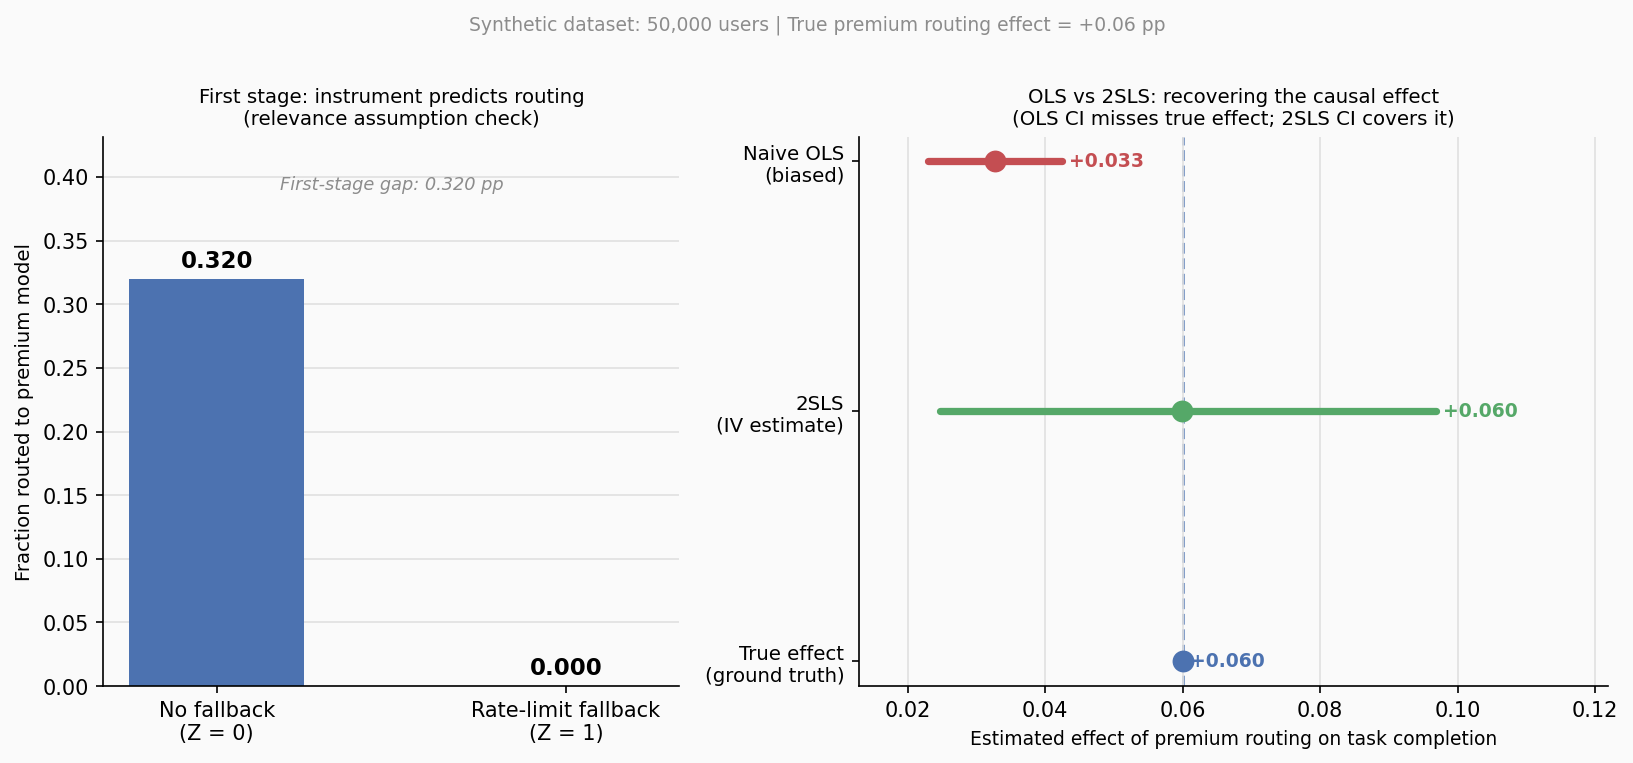

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image

# Display the pre-generated figure
Image("iv_first_stage_estimates.png")
